In [1]:
from databricks.connect import DatabricksSession

# Create the spark session
spark = DatabricksSession.builder.serverless().getOrCreate()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# Convert the Spark DataFrame to a Pandas DataFrame
def safe_to_pandas(sdf):
    # Cast date/timestamp columns to string to avoid out-of-range datetime conversion errors
    exprs = [
        f"CAST(`{col}` AS STRING) AS `{col}`" if dtype in ("date", "timestamp") else f"`{col}`"
        for col, dtype in sdf.dtypes
    ]
    return sdf.selectExpr(*exprs).toPandas()

In [ ]:
all_crises = spark.sql("SELECT * FROM workspace.default.inform_severity_index_sig")
all_crises_pd = safe_to_pandas(all_crises)

In [6]:
all_crises_pd = pd.read_csv('all_crises.csv')
all_allocations = pd.read_csv('C:/Users/Asus/Downloads/full_pfmb_allocations.csv')

C:\Users\Asus\AppData\Local\Temp\ipykernel_18872\2443333805.py:2: DtypeWarning: Columns (6,20) have mixed types. Specify dtype option on import or set low_memory=False.
  all_allocations = pd.read_csv('C:/Users/Asus/Downloads/full_pfmb_allocations.csv')


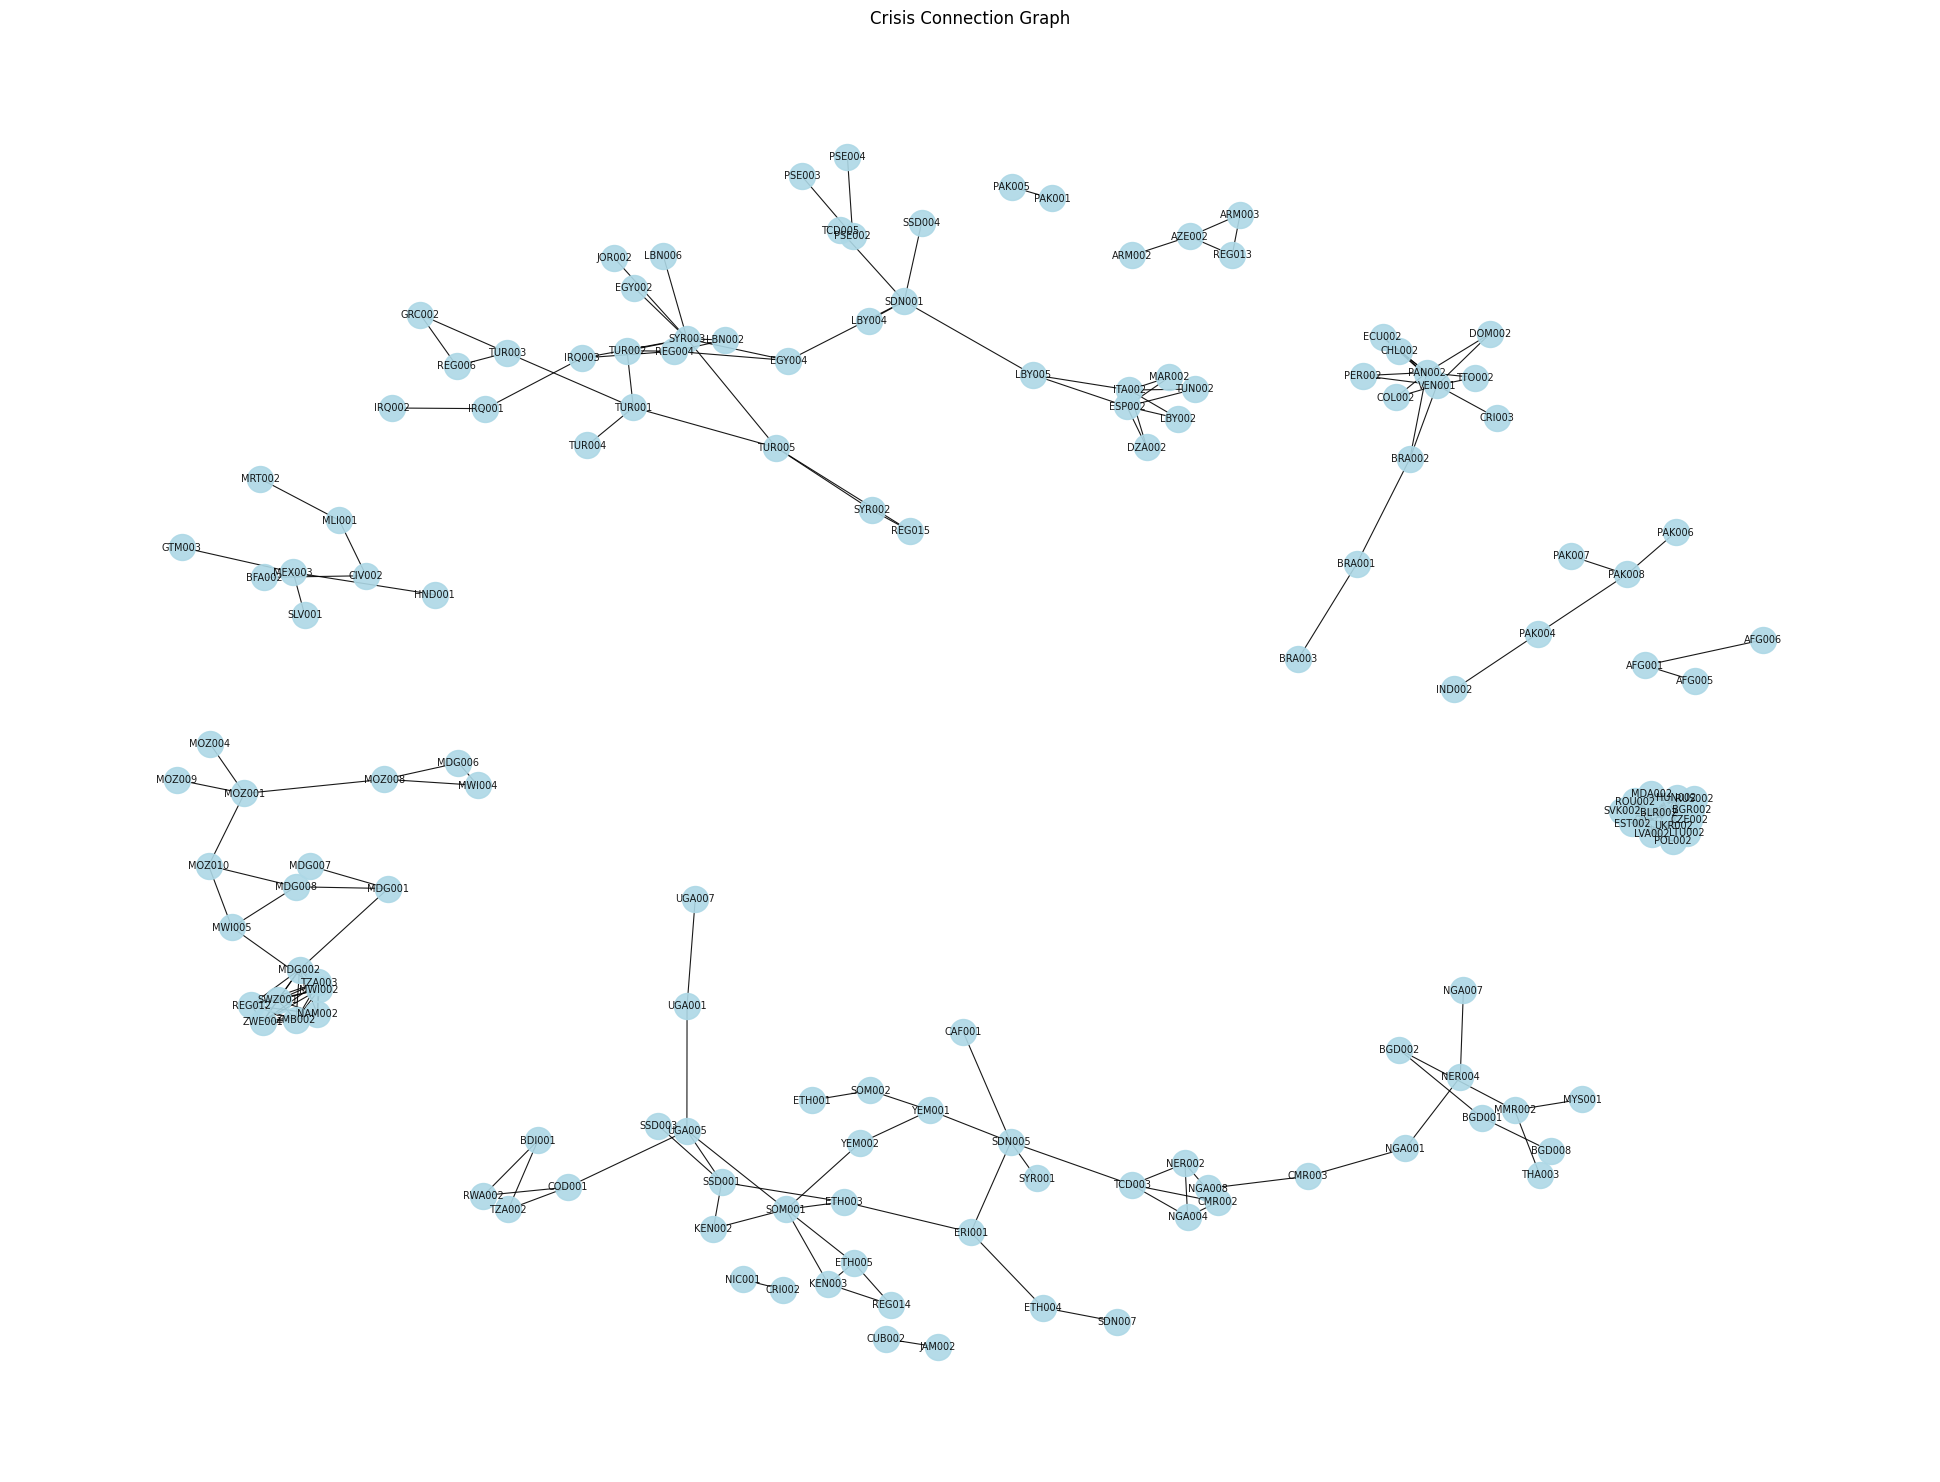

In [7]:
crisis_graph = all_crises_pd[['crisis_id', 'connected_crises']].drop_duplicates()

# Plot a graph where each node is a crisis and edges represent connections between crises
def parse_iso3(val):
    try:
        lst = ast.literal_eval(val)
        return lst
    except Exception:
        return np.nan

crisis_graph['connected_crises'] = crisis_graph['connected_crises'].apply(parse_iso3)

G = nx.Graph()
nodes = crisis_graph['crisis_id'].unique()
G.add_nodes_from(nodes)
for _, row in crisis_graph.iterrows():
    if row['connected_crises'] is np.nan:
        continue
    for conn in row['connected_crises']:
        if conn in nodes:
            G.add_edge(row['crisis_id'], conn)
# Remove isolated nodes (crises with no connections)
G.remove_nodes_from(list(nx.isolates(G)))
            
plt.figure(figsize=(16*1.2, 12*1.2)) 

pos = nx.spring_layout(G, k=0.3, iterations=100, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=350,
    node_color='lightblue',
    font_size=7,
    width=0.8,
    alpha=0.9
)
plt.title("Crisis Connection Graph")
plt.show()

In [8]:

# ── 1. Explore allocation columns to find the amount field ──────────────────
print("All columns in all_allocations:")
print(all_allocations.columns.tolist())
print("\nDtype summary:")
print(all_allocations.dtypes)


All columns in all_allocations:
['ProjectStatus', 'ChfId', 'AllocationYear', 'ChfProjectCode', 'ProjectTitle', 'ApplicationID', 'ApplicationCode', 'AllocationSourceName', 'PooledFundName', 'CountryCode', 'PartnerCode', 'OrganizationName', 'AgencyShortName', 'EmergencyTypeName', 'EmergencyGroupForGlobalReporting', 'Budget', 'ProjectSectorName', 'ProjectStartDate', 'ProjectEndDate', 'ApprovedDate', 'EmergencyGroupName', 'EmergencyCategoryName', 'RegionName', 'SubRegionName', 'ContinentName', 'ProjectTypeName', 'GenderMarker', 'GenderMarkerType', 'FundType', 'AllocationType', 'OrganizationType', 'ProjectDuration', 'DateSubmitted', 'ActualStartDate', 'ActualEndDate']

Dtype summary:
ProjectStatus                        object
ChfId                                 int64
AllocationYear                        int64
ChfProjectCode                       object
ProjectTitle                         object
ApplicationID                         int64
ApplicationCode                      object
Allo

In [9]:
# ── 2. Clean allocations: extract country ISO3 and year ────────────────────
alloc = all_allocations.copy()
alloc['year'] = alloc['AllocationYear'].astype(int)
alloc['iso3'] = alloc['CountryCode'].str.strip().str.upper()


In [10]:
all_allocations

,ProjectStatus,ChfId,AllocationYear,ChfProjectCode,ProjectTitle,ApplicationID,ApplicationCode,AllocationSourceName,PooledFundName,CountryCode,...,ProjectTypeName,GenderMarker,GenderMarkerType,FundType,AllocationType,OrganizationType,ProjectDuration,DateSubmitted,ActualStartDate,ActualEndDate
0,Report Available,1,2006,06-FAO-010-A,Immediate support to pastoral communities as a...,235,06-RR-DJI-4523,Rapid Response,Djibouti,DJI,...,NON-HRP,NaN,GM,CERF,,UN Agency,,,,
1,Report Available,2,2006,06-FAO-010-B,Immediate support to pastoral communities as a...,256,06-RR-ERI-4900,Rapid Response,Eritrea,ERI,...,NON-HRP,NaN,GM,CERF,,UN Agency,,,,
2,Report Available,3,2006,06-FAO-010-C,Immediate support to pastoral communities as a...,270,06-RR-ETH-5075,Rapid Response,Ethiopia,ETH,...,NON-HRP,NaN,GM,CERF,,UN Agency,,,,
3,Report Available,4,2006,06-FAO-010-D,Immediate support to pastoral communities as a...,392,06-RR-KEN-6267,Rapid Response,Kenya,KEN,...,NON-HRP,NaN,GM,CERF,,UN Agency,,,,
4,Report Available,5,2006,06-FAO-010-E,Immediate support to pastoral communities as a...,659,06-RR-SOM-10619,Rapid Response,Somalia,SOM,...,NON-HRP,NaN,GM,CERF,,UN Agency,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25105,Implementation,37950,2025,CBPF-YEM-25-S-NGO-37950,Emergency life saving food and protection Assi...,-1,-1,Standard,Yemen,YEM,...,,NaN,NaN,CBPF,2nd Standard Allocation 2025,National NGO,12 Months,10/19/2025 7:28:37 AM,3/1/2026 12:00:00 AM,2/28/2027 12:00:00 AM
25106,Implementation,37987,2025,CBPF-YEM-25-S-UN-37987,Cash Assistance to meet immediate food needs o...,-1,-1,Standard,Yemen,YEM,...,,NaN,NaN,CBPF,2nd Standard Allocation 2025,UN Agency,12 Months,10/19/2025 11:51:53 AM,3/1/2026 12:00:00 AM,2/28/2027 12:00:00 AM
25107,Implementation,37991,2025,CBPF-YEM-25-S-NGO-37991,"Integrated CASH, Shelter, and WASH, Project fo...",-1,-1,Standard,Yemen,YEM,...,,NaN,NaN,CBPF,2nd Standard Allocation 2025,National NGO,12 Months,10/19/2025 9:07:46 AM,3/1/2026 12:00:00 AM,2/28/2027 12:00:00 AM
25108,Implementation,38009,2025,CBPF-YEM-25-S-NGO-38009,integrate Life-Saving Response (Multi-Purpose ...,-1,-1,Standard,Yemen,YEM,...,,NaN,NaN,CBPF,2nd Standard Allocation 2025,National NGO,8 Months,10/19/2025 9:16:34 AM,3/1/2026 12:00:00 AM,10/31/2026 12:00:00 AM


In [11]:
# ── 3. Set the correct budget column name here ─────────────────────────────
# After running cell 2, pick the right column from budget_candidates
BUDGET_COL = 'Budget'
print(f"Using budget column: {BUDGET_COL}")

if BUDGET_COL:
    alloc[BUDGET_COL] = pd.to_numeric(alloc[BUDGET_COL], errors='coerce')
    # Aggregate total funding per country per year
    funding_by_country_year = (
        alloc.groupby(['iso3', 'year'])[BUDGET_COL]
        .sum()
        .reset_index()
        .rename(columns={BUDGET_COL: 'total_funding'})
    )
    print(funding_by_country_year.head(10))
else:
    print("No budget column found — check column names above and set BUDGET_COL manually.")


Using budget column: Budget
  iso3  year  total_funding
0  AFG  2006    32304626.61
1  AFG  2007     5434407.00
2  AFG  2008    18220644.12
3  AFG  2009     4165567.00
4  AFG  2010    11019952.00
5  AFG  2012     9995396.00
6  AFG  2013    16574042.00
7  AFG  2014    38761006.57
8  AFG  2015    51547508.07
9  AFG  2016    49536608.49


In [23]:
severity_cols = [
    'Impact of the crisis', 'Geographical Impact', "Human Impact",'Conditions of affected people', 'People in need',
    'Concentration of conditions', 'Complexity', 'Society and safety',
    'Operating environment'
]

crises = all_crises_pd.copy()

# Parse iso3 from string-list like "['AFG']" → 'AFG'
def parse_iso3(val):
    try:
        lst = ast.literal_eval(val)
        # return a new row for each iso3 in the list, or np.nan if the list is empty
        return lst if lst else np.nan
    except Exception:
        return np.nan
    
crises['iso3'] = crises['iso3'].apply(parse_iso3)
crises = crises.explode('iso3', ignore_index=True)

crises['year'] = crises['period'].str.extract(r'(\d{4})').astype(int)

avg_crisis_by_country_year = (
    crises.groupby(['iso3', 'year', 'crisis_id'])
    .agg(
        mean_severity=('INFORM Severity Index', 'mean'),
        max_severity=('INFORM Severity Index', 'max'),
        **{col.replace(' ', '_').lower(): (col, 'mean') for col in severity_cols}
    )
    .reset_index()
)

def exponential_adding(vals):
    return np.log(np.sum(np.exp(vals)) + 1e-9)  # Add a small constant to prevent log(0)

crisis_by_country_year = (
    avg_crisis_by_country_year.groupby(['iso3', 'year'])
    .agg(
        total_severity=('mean_severity', exponential_adding),
        max_severity=('max_severity', 'max'),
        **{col: (col, exponential_adding) for col in [i.replace(' ', '_').lower() for i in severity_cols]}
    )
    .reset_index()
)

crisis_by_country_year = crisis_by_country_year[crisis_by_country_year['total_severity'] > 0]

In [25]:
# ── 5. Merge funding + crises on (iso3, year) ──────────────────────────────
# Crisis data: 2020–2025 | Allocation data: starts 2006
# We inner-join to keep only overlapping country-years
merged = crisis_by_country_year.merge(funding_by_country_year, on=['iso3', 'year'], how='inner')
print(f"Merged shape: {merged.shape}")
print(f"Countries: {merged['iso3'].nunique()} | Years: {sorted(merged['year'].unique())}")
merged.head()


Merged shape: (244, 14)
Countries: 69 | Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,iso3,year,total_severity,max_severity,impact_of_the_crisis,geographical_impact,human_impact,conditions_of_affected_people,people_in_need,concentration_of_conditions,complexity,society_and_safety,operating_environment,total_funding
0,AFG,2020,8.866667,8.9,9.848459,9.855131,9.844450,8.919324,9.838649,8.000000,7.869610,6.133164,9.000000,1.022745e+08
1,AFG,2021,9.158333,9.2,9.935142,9.855131,9.973060,9.262867,10.000000,8.525735,8.227569,6.520450,9.291667,2.581289e+08
2,AFG,2022,8.967999,9.0,9.593037,9.855431,9.503434,9.038162,10.008161,8.136768,8.353236,7.278507,9.313974,2.926707e+08
3,AFG,2023,9.002946,9.0,9.584133,9.856222,9.620403,9.056780,10.011724,8.270553,8.401817,7.746428,9.246967,1.885800e+08
4,AFG,2024,8.751949,8.8,9.628091,9.855866,9.501638,9.034300,10.005489,8.199855,7.641482,7.377657,8.151300,5.521333e+07


In [26]:
# ── 6. Correlation analysis ────────────────────────────────────────────────

severity_agg_cols = ['total_severity', 'max_severity'] + [
    col.replace(' ', '_').lower() for col in severity_cols
]

print("Pearson correlations with total_funding:\n")
results = []
for col in severity_agg_cols:
    sub = merged[['total_funding', col]].dropna()
    r, p = stats.pearsonr(sub['total_funding'], sub[col])
    results.append({'severity_dimension': col, 'pearson_r': round(r, 3), 'p_value': round(p, 4)})

corr_df = pd.DataFrame(results).sort_values('pearson_r', ascending=False)
print(corr_df.to_string(index=False))


Pearson correlations with total_funding:

           severity_dimension  pearson_r  p_value
                 max_severity      0.521      0.0
         impact_of_the_crisis      0.478      0.0
               total_severity      0.465      0.0
                 human_impact      0.444      0.0
conditions_of_affected_people      0.424      0.0
  concentration_of_conditions      0.422      0.0
                   complexity      0.411      0.0
        operating_environment      0.410      0.0
          geographical_impact      0.349      0.0
               people_in_need      0.347      0.0
           society_and_safety      0.303      0.0


In [27]:
# ── 7. Time-lag analysis: does severity in year T predict funding in T+1? ──
lag_rows = []
for lag in [0, 1, 2]:
    lagged = crisis_by_country_year.copy()
    lagged['year'] = lagged['year'] + lag          # shift crises forward
    sub = lagged.merge(funding_by_country_year, on=['iso3', 'year'], how='inner')
    sub = sub[['total_funding', 'total_severity']].dropna()
    if len(sub) > 5:
        r, p = stats.pearsonr(sub['total_funding'], sub['total_severity'])
        lag_rows.append({'lag_years': lag, 'n_obs': len(sub), 'pearson_r': round(r, 3), 'p_value': round(p, 4)})

print("Lag analysis (severity in year T → funding in year T+lag):\n")
print(pd.DataFrame(lag_rows).to_string(index=False))


Lag analysis (severity in year T → funding in year T+lag):

 lag_years  n_obs  pearson_r  p_value
         0    244      0.465      0.0
         1    209      0.424      0.0
         2    174      0.397      0.0


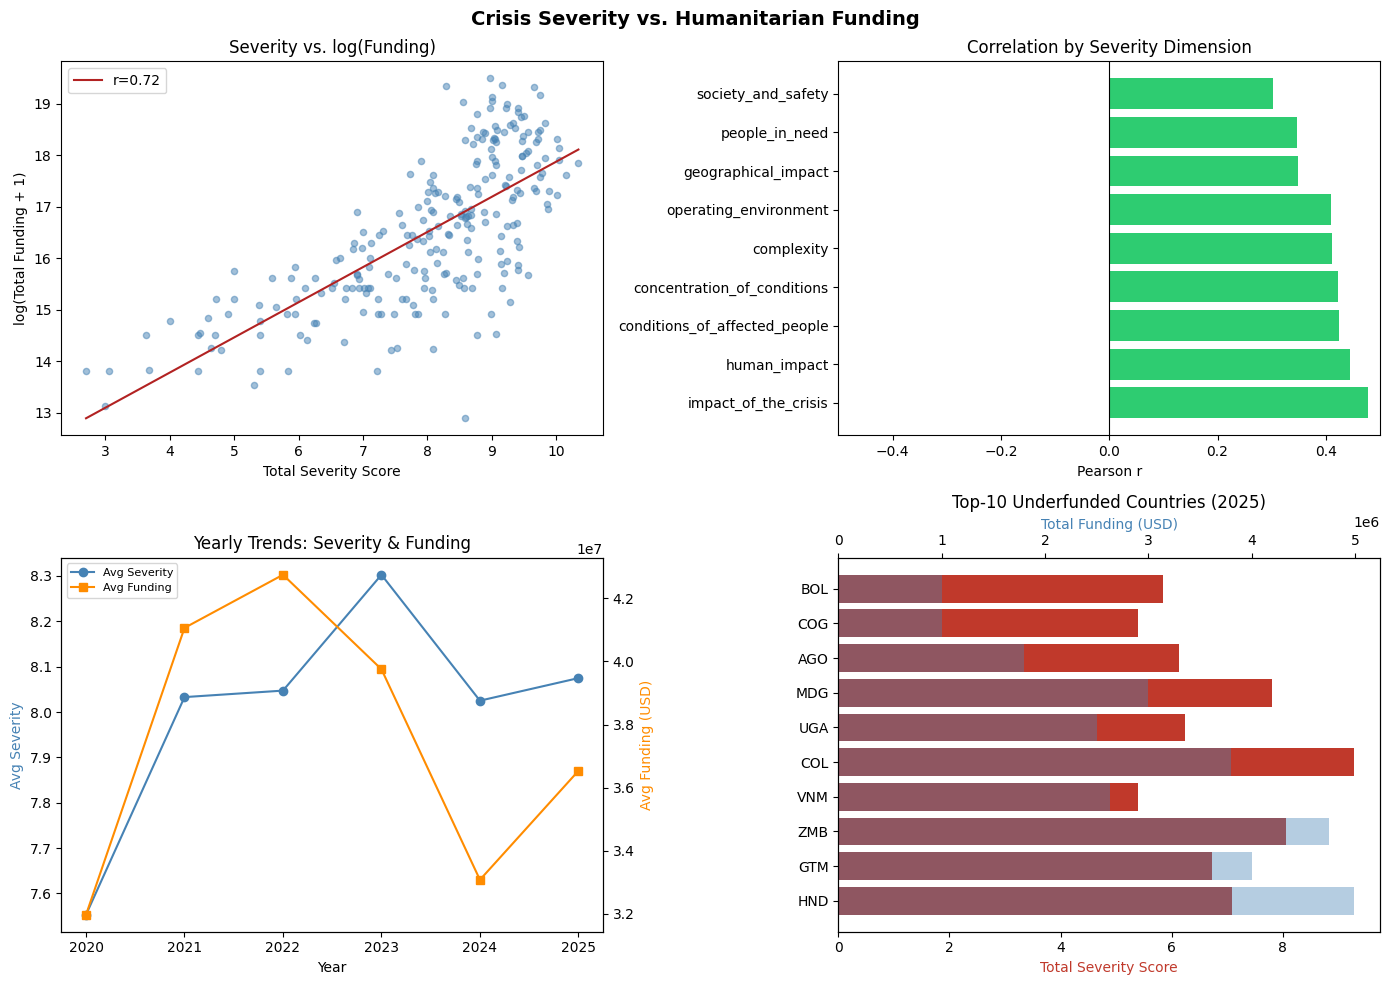

In [28]:
# ── 8. Visualizations ─────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Crisis Severity vs. Humanitarian Funding", fontsize=14, fontweight='bold')

# 8a. Scatter: avg_severity vs log(total_funding)
ax = axes[0, 0]
log_funding = np.log1p(merged['total_funding'])
ax.scatter(merged['total_severity'], log_funding, alpha=0.5, s=20, color='steelblue')
m, b, r, p, _ = stats.linregress(merged['total_severity'].dropna(), log_funding[merged['total_severity'].notna()])
xs = np.linspace(merged['total_severity'].min(), merged['total_severity'].max(), 100)
ax.plot(xs, m * xs + b, color='firebrick', linewidth=1.5, label=f'r={r:.2f}')
ax.set_xlabel('Total Severity Score')
ax.set_ylabel('log(Total Funding + 1)')
ax.set_title('Severity vs. log(Funding)')
ax.legend()

# 8b. Bar: correlation of each severity dimension with funding
ax = axes[0, 1]
corr_df_plot = corr_df[corr_df['severity_dimension'].isin(
    [c.replace(' ', '_').lower() for c in severity_cols]
)].copy()
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in corr_df_plot['pearson_r']]
ax.barh(corr_df_plot['severity_dimension'], corr_df_plot['pearson_r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r')
ax.set_title('Correlation by Severity Dimension')
ax.set_xlim(-0.5, 0.5)

# 8c. Yearly trend: avg severity and avg funding (normalized)
ax = axes[1, 0]
trend = merged.groupby('year').agg(
    avg_sev=('total_severity', 'mean'),
    avg_fund=('total_funding', 'mean')
).reset_index()
ax2 = ax.twinx()
ax.plot(trend['year'], trend['avg_sev'], marker='o', color='steelblue', label='Avg Severity')
ax2.plot(trend['year'], trend['avg_fund'], marker='s', color='darkorange', label='Avg Funding')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Severity', color='steelblue')
ax2.set_ylabel('Avg Funding (USD)', color='darkorange')
ax.set_title('Yearly Trends: Severity & Funding')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# 8d. Top-10 underfunded countries (high severity, low funding) in latest year
ax = axes[1, 1]
latest_year = merged['year'].max()
latest = merged[merged['year'] == latest_year].copy()
latest['funding_per_severity'] = latest['total_funding'] / (latest['total_severity'] + 1e-6)
top10 = latest.nsmallest(10, 'funding_per_severity')
ax.barh(top10['iso3'], top10['total_severity'], color='#c0392b', label='Severity')
ax2b = ax.twiny()
ax2b.barh(top10['iso3'], top10['total_funding'], alpha=0.4, color='steelblue', label='Funding')
ax.set_xlabel('Total Severity Score', color='#c0392b')
ax2b.set_xlabel('Total Funding (USD)', color='steelblue')
ax.set_title(f'Top-10 Underfunded Countries ({latest_year})')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('severity_vs_funding.png', dpi=150, bbox_inches='tight')
plt.show()


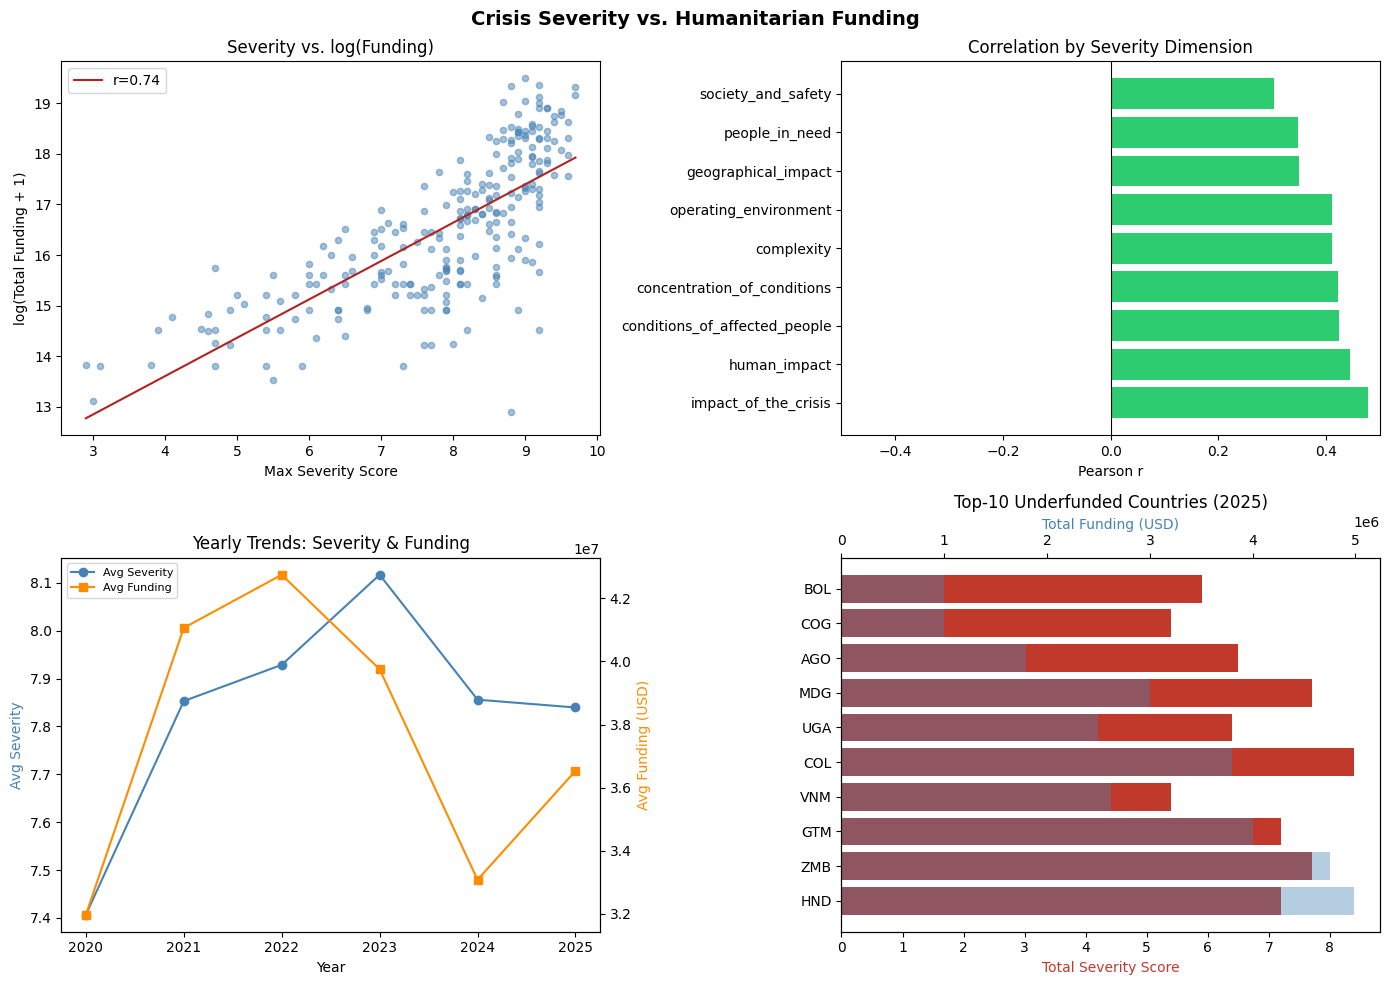

In [29]:
# ── 8.5 . Visualizations ─────────────────────────────────────────────────────
# Same as 8 but this time using max_severity instead of total_severity, to see if the max severity of any crisis in a country-year has a stronger correlation with funding than the sum of severities.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Crisis Severity vs. Humanitarian Funding", fontsize=14, fontweight='bold')

# 8a. Scatter: avg_severity vs log(total_funding)
ax = axes[0, 0]
log_funding = np.log1p(merged['total_funding'])
ax.scatter(merged['max_severity'], log_funding, alpha=0.5, s=20, color='steelblue')
m, b, r, p, _ = stats.linregress(merged['max_severity'].dropna(), log_funding[merged['max_severity'].notna()])
xs = np.linspace(merged['max_severity'].min(), merged['max_severity'].max(), 100)
ax.plot(xs, m * xs + b, color='firebrick', linewidth=1.5, label=f'r={r:.2f}')
ax.set_xlabel('Max Severity Score')
ax.set_ylabel('log(Total Funding + 1)')
ax.set_title('Severity vs. log(Funding)')
ax.legend()

# 8b. Bar: correlation of each severity dimension with funding
ax = axes[0, 1]
corr_df_plot = corr_df[corr_df['severity_dimension'].isin(
    [c.replace(' ', '_').lower() for c in severity_cols]
)].copy()
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in corr_df_plot['pearson_r']]
ax.barh(corr_df_plot['severity_dimension'], corr_df_plot['pearson_r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r')
ax.set_title('Correlation by Severity Dimension')
ax.set_xlim(-0.5, 0.5)

# 8c. Yearly trend: avg severity and avg funding (normalized)
ax = axes[1, 0]
trend = merged.groupby('year').agg(
    avg_sev=('max_severity', 'mean'),
    avg_fund=('total_funding', 'mean')
).reset_index()
ax2 = ax.twinx()
ax.plot(trend['year'], trend['avg_sev'], marker='o', color='steelblue', label='Avg Severity')
ax2.plot(trend['year'], trend['avg_fund'], marker='s', color='darkorange', label='Avg Funding')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Severity', color='steelblue')
ax2.set_ylabel('Avg Funding (USD)', color='darkorange')
ax.set_title('Yearly Trends: Severity & Funding')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# 8d. Top-10 underfunded countries (high severity, low funding) in latest year
ax = axes[1, 1]
latest_year = merged['year'].max()
latest = merged[merged['year'] == latest_year].copy()
latest['funding_per_severity'] = latest['total_funding'] / (latest['max_severity'] + 1e-6)
top10 = latest.nsmallest(10, 'funding_per_severity')
ax.barh(top10['iso3'], top10['max_severity'], color='#c0392b', label='Severity')
ax2b = ax.twiny()
ax2b.barh(top10['iso3'], top10['total_funding'], alpha=0.4, color='steelblue', label='Funding')
ax.set_xlabel('Total Severity Score', color='#c0392b')
ax2b.set_xlabel('Total Funding (USD)', color='steelblue')
ax.set_title(f'Top-10 Underfunded Countries ({latest_year})')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('severity_vs_funding.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ── 9. Summary statistics: funding gap analysis ────────────────────────────
# Rank countries by severity and by funding within each year; compare ranks
merged['severity_rank'] = merged.groupby('year')['total_severity'].rank(ascending=False)
merged['funding_rank'] = merged.groupby('year')['total_funding'].rank(ascending=False)
merged['rank_gap'] = merged['severity_rank'] - merged['funding_rank']  # positive = underfunded

# Countries most consistently underfunded relative to severity
rank_gap_summary = (
    merged.groupby('iso3')['rank_gap']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_rank_gap', 'count': 'years_observed'})
    .query('years_observed >= 2')
    .sort_values('avg_rank_gap', ascending=False)
)

print("Most underfunded relative to severity (positive = severity rank > funding rank):")
print(rank_gap_summary.head(15).to_string())
print("\nMost overfunded relative to severity:")
print(rank_gap_summary.tail(10).to_string())


Most underfunded relative to severity (positive = severity rank > funding rank):
      avg_rank_gap  years_observed
iso3                              
UKR      22.500000               6
AFG      20.166667               6
COD      19.500000               6
CAF      16.500000               6
SSD      16.000000               6
YEM      14.500000               6
PSE      13.333333               6
BFA      11.666667               6
MLI      11.200000               5
HTI      10.500000               6
SDN       8.500000               6
SOM       8.166667               6
SYR       7.000000               6
HND       4.800000               5
ERI       3.666667               3

Most overfunded relative to severity:
      avg_rank_gap  years_observed
iso3                              
EGY     -12.500000               2
MDG     -12.666667               6
NER     -13.000000               6
TCD     -15.333333               6
PHL     -16.250000               4
DJI     -17.000000               3
LBY  